Predicting and Classifying Learning Outcomes with ML

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


In [2]:
education_df = pd.read_csv("dataset_Final_Project_CSML.csv")
education_df.head() 
education_df.info()
education_df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   State                  153 non-null    object 
 1   Total expenditures     153 non-null    int64  
 2   student_teacher_ratio  153 non-null    float64
 3   per-pupil_spending     153 non-null    int64  
 4   Median_Income          153 non-null    object 
 5   Poverty Rate           153 non-null    float64
 6   Urbanization           153 non-null    float64
 7   Teacher_Salary         153 non-null    int64  
 8   Graduation_Rate        153 non-null    float64
 9   Year                   153 non-null    int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 12.1+ KB


,Total expenditures,student_teacher_ratio,per-pupil_spending,Poverty Rate,Urbanization,Teacher_Salary,Graduation_Rate,Year
count,1.530000e+02,153.000000,153.000000,153.000000,153.000000,1.530000e+02,153.000000,153.00000
mean,1.134181e+10,15.730719,10770.810458,13.019608,73.110458,2.919782e+09,79.045752,2010.00000
std,1.469729e+10,2.779916,4401.762975,3.259804,15.030290,3.570481e+09,8.515388,8.19178
min,7.247356e+08,10.800000,4378.000000,6.500000,35.100000,2.586780e+08,54.500000,2000.00000
25%,2.689838e+09,13.900000,7425.000000,10.500000,63.600000,7.846006e+08,75.200000,2000.00000
50%,6.924814e+09,15.100000,9846.000000,12.500000,73.100000,1.806721e+09,80.800000,2010.00000
75%,1.305497e+10,17.000000,13023.000000,15.300000,86.300000,3.341705e+09,84.900000,2020.00000
max,9.898620e+10,23.800000,26441.000000,22.400000,100.000000,2.067122e+10,92.100000,2020.00000


(153, 10)


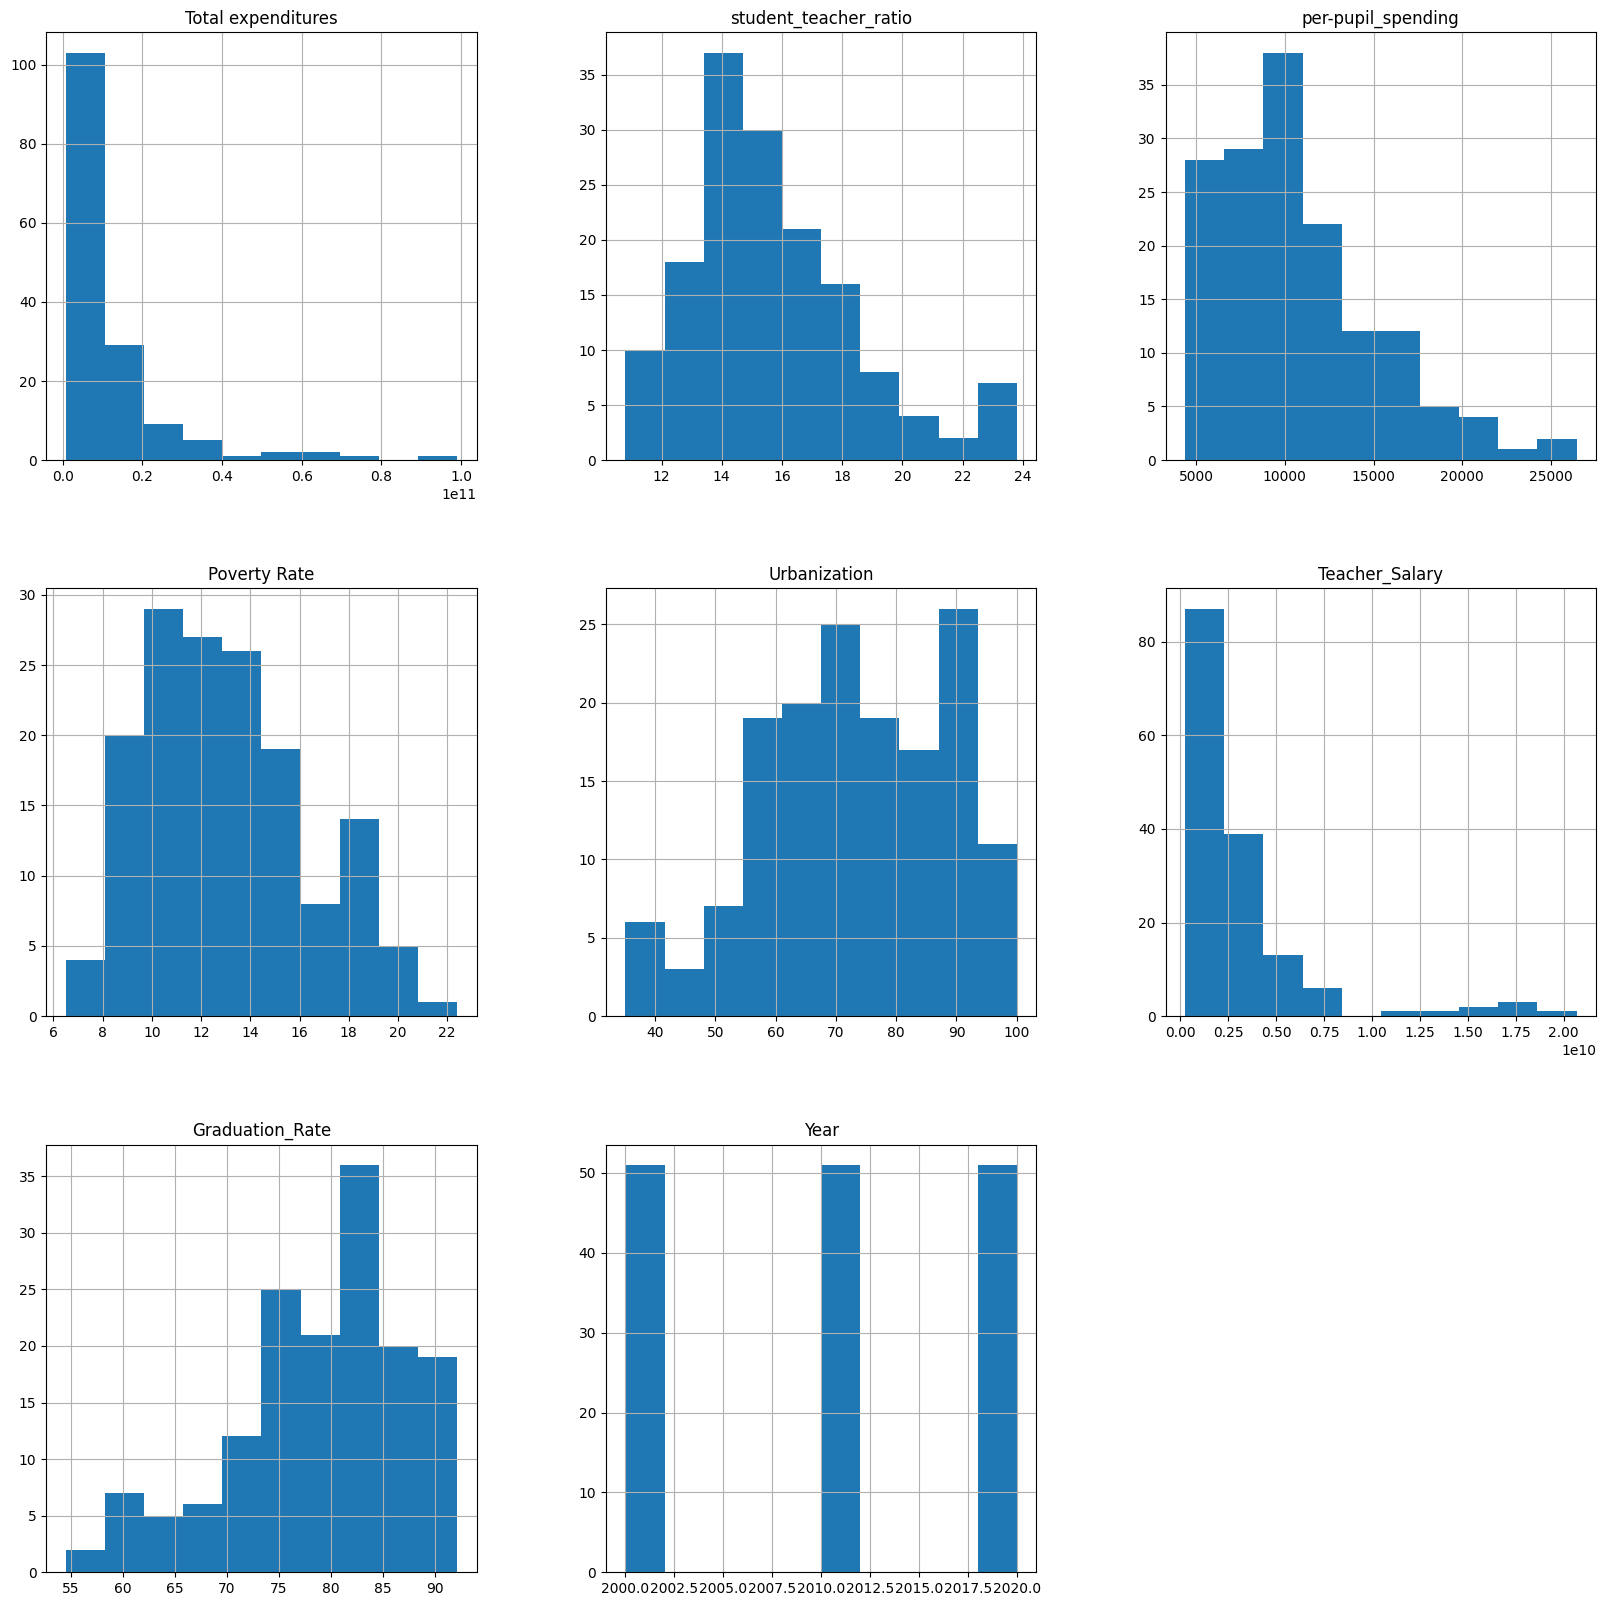

In [3]:
print(education_df.shape)
education_df.hist(figsize=(20, 20))
plt.show()

In [4]:
df_encoded = pd.get_dummies(education_df, columns=['State'], prefix='State')

# 4. Save the new dataset
output_filename = "combined_encoded_education_data.csv"
df_encoded.to_csv(output_filename, index=False)

# Optional: View the new shape and first few rows
print(f"New dataset shape: {df_encoded.shape}")
print(df_encoded.head())

New dataset shape: (153, 60)
   Total expenditures  student_teacher_ratio  per-pupil_spending  \
0          4935621221                   15.4                5638   
1          1375232700                   16.9                8806   
2          5588398292                   19.8                4999   
3          2628202265                   14.1                5277   
4         44459535249                   20.6                6314   

  Median_Income  Poverty Rate  Urbanization  Teacher_Salary  Graduation_Rate  \
0        44,667          16.1          55.4      1880267638             64.1   
1        67,483           9.4          65.6       450803336             66.7   
2        53,072          13.9          88.2      1787356212             63.6   
3        42,111          15.8          52.5      1084819850             74.6   
4        62,147          14.2          94.4     17023740804             71.7   

   Year  State_Alabama  ...  State_South Dakota  State_Tennessee  State_Texas  \


In [5]:
num_cols = df_encoded.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df_encoded[num_cols].corr()

# 7. Create and save the correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Educational Features (2000-2020 Combined)")
plt.tight_layout()
plt.savefig("fixed_correlation_heatmap.png")
plt.close()

In [31]:
df_encoded = pd.read_csv("combined_encoded_education_data.csv")

state_cols = [col for col in df_encoded.columns if col.startswith('State_')]
non_state_cols = [col for col in df_encoded.columns if col not in state_cols]

for col in non_state_cols:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = (
            df_encoded[col]
            .astype(str)
            .str.replace(',', '', regex=False)
            .str.strip()
        )
    df_encoded[col] = pd.to_numeric(df_encoded[col], errors='coerce')

df_encoded[non_state_cols] = df_encoded[non_state_cols].astype('float64')

cols_to_exclude = ['Year', 'Graduation_Rate'] + state_cols

df_encoded = df_encoded.drop(columns=['Teacher_Salary'])
df_encoded = df_encoded.drop(columns=['Total expenditures'])
df_encoded = df_encoded.drop(columns=state_cols)

cols_to_scale = [col for col in df_encoded.select_dtypes(include=['float64', 'int64']).columns if col not in cols_to_exclude]

# initial_rows = len(df_encoded)
# df_encoded = df_encoded.dropna(subset=[ 'Total expenditures'])
# removed_rows = initial_rows - len(df_encoded)
# print(f"Removed {removed_rows} rows with NaNs")

# with np.errstate(invalid='ignore'):  # Suppress warnings if any occur
#     # df_encoded['Teacher_Salary'] = np.log1p(df_encoded['Teacher_Salary'])
#     df_encoded['Total expenditures'] = np.log1p(df_encoded['Total expenditures'])


scaler = StandardScaler()

df_encoded[cols_to_scale] = scaler.fit_transform(df_encoded[cols_to_scale])

df_encoded.to_csv("final_preprocessed_education_data.csv", index=False)

print(f"\nFinal dataset shape: {df_encoded.shape}")
print(f"NaNs in scaled data: {df_encoded[cols_to_scale].isna().sum().sum()}")
print(df_encoded[cols_to_scale].head())


Final dataset shape: (153, 7)
NaNs in scaled data: 0
   student_teacher_ratio  per-pupil_spending  Median_Income  Poverty Rate  \
0              -0.119358           -1.169910      -1.055766      0.948066   
1               0.421999           -0.447835       0.781957     -1.114022   
2               1.468622           -1.315556      -0.378782      0.270962   
3              -0.588534           -1.252192      -1.261639      0.855733   
4               1.757345           -1.015831       0.352167      0.363294   

   Urbanization  
0     -1.182187  
1     -0.501329  
2      1.007239  
3     -1.375765  
4      1.421094  


In [32]:
from sklearn.model_selection import cross_val_predict
lm = LinearRegression()

cols_Exclude = ['Graduation_Rate'] + [col for col in df_encoded.columns if col.startswith('State_')]

X = df_encoded[[col for col in df_encoded.columns if col not in cols_Exclude]]
y = df_encoded['Graduation_Rate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=200)


# lm.fit(X_train,y_train)

In [33]:
from sklearn import metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold, cross_val_score

# predicts = lm.predict(X_test)

# print("""
#         Mean Absolute Error: {}
#         Root Mean Squared Error: {}
#         R2 Score: {}
#      """.format(
#         mean_absolute_error(y_test,predicts),
#         np.sqrt(metrics.mean_squared_error(y_test, predicts)),
#         r2_score(y_test,predicts),
#         ))

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_mse = cross_val_score(lm, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')

cv_rmse = np.sqrt(-cv_scores_mse)

print(f"Cross-Validation RMSE across 5 folds: {cv_rmse}")
print(f"Average CV RMSE: {cv_rmse.mean():.2f}")
print("-" * 30)

lm.fit(X_train, y_train)

test_predictions = lm.predict(X_test)

final_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
final_r2 = r2_score(y_test, test_predictions)

print(f"Final Test RMSE: {final_rmse:.2f}")
print(f"Final Test R2 Score: {final_r2:.2f}")

Cross-Validation RMSE across 5 folds: [6.00665638 5.38750519 4.18481988 6.25557656 5.9893082 ]
Average CV RMSE: 5.56
------------------------------
Final Test RMSE: 3.90
Final Test R2 Score: 0.80


In [38]:
df_clean = pd.read_csv("final_preprocessed_education_data.csv")
features = [
    'per-pupil_spending', 
    'Poverty Rate', 
    'Urbanization', 
    'Median_Income', 
    'student_teacher_ratio'
]

X_fresh = df_clean[features].copy()
y_fresh = df_clean['Graduation_Rate'].copy()

scaler = StandardScaler()
X_scaled_fresh = pd.DataFrame(scaler.fit_transform(X_fresh), columns=X_fresh.columns)


model_fresh = lm
model_fresh.fit(X_scaled_fresh, y_fresh)


coef_df = pd.DataFrame({
    'Feature': X_scaled_fresh.columns,
    'Coefficient': model_fresh.coef_
}).sort_values(by='Coefficient', ascending=False)

print("--- TRUE CLEAN COEFFICIENTS ---")
print(coef_df.to_string(index=False))

--- TRUE CLEAN COEFFICIENTS ---
              Feature  Coefficient
   per-pupil_spending     3.366397
student_teacher_ratio     0.888280
        Median_Income     0.726024
         Poverty Rate    -2.646529
         Urbanization    -2.867704


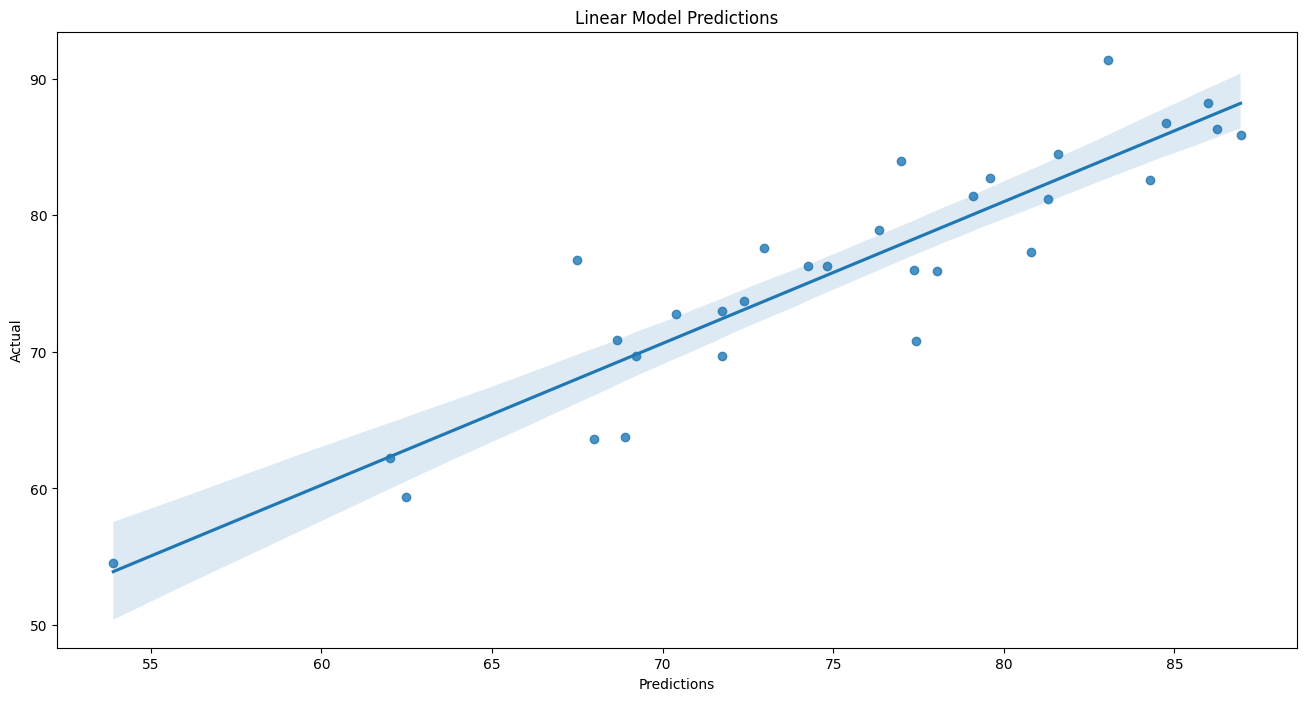

In [10]:
plt.figure(figsize=(16,8))
sns.regplot(x=test_predictions, y=y_test)
plt.xlabel('Predictions')
plt.ylabel('Actual')
plt.title("Linear Model Predictions")
plt.grid(False)
plt.show()

In [11]:
from sklearn import linear_model

clf = linear_model.BayesianRidge()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=200)

# clf.fit(X_train, y_train)

In [12]:
# predicts = clf.predict(X_test)

# print("""
#         Mean Absolute Error: {}
#         Root Mean Squared Error: {}
#         R2 Score: {}
#      """.format(
#         mean_absolute_error(y_test,predicts),
#         np.sqrt(metrics.mean_squared_error(y_test, predicts)),
#         r2_score(y_test,predicts),
#         ))

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_mse = cross_val_score(clf, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')

cv_rmse = np.sqrt(-cv_scores_mse)

print(f"Cross-Validation RMSE across 5 folds: {cv_rmse}")
print(f"Average CV RMSE: {cv_rmse.mean():.2f}")
print("-" * 30)

clf.fit(X_train, y_train)

test_predictions = clf.predict(X_test)

final_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
final_r2 = r2_score(y_test, test_predictions)

print(f"Final Test RMSE: {final_rmse:.2f}")
print(f"Final Test R2 Score: {final_r2:.2f}")

Cross-Validation RMSE across 5 folds: [5.40660805 5.96639622 4.93366806 6.22495278 5.9915395 ]
Average CV RMSE: 5.70
------------------------------
Final Test RMSE: 3.80
Final Test R2 Score: 0.81


In [ ]:
# coef_df_2 = pd.DataFrame({
#     'Feature': X.columns,
#     'Coefficient': clf.coef_
# })

# coef_df_2['Absolute_Impact'] = coef_df_2['Coefficient'].abs()
# coef_df_2 = coef_df_2.sort_values(by='Absolute_Impact', ascending=False)

# coef_df_2 = coef_df_2.drop(columns=['Absolute_Impact'])
# print("Feature Coefficients (Impact on Graduation Rate):")
# print("-" * 50)
# print(coef_df_2.to_string(index=False))

df_clean = pd.read_csv("final_preprocessed_education_data.csv")
features = [
    'per-pupil_spending', 
    'Poverty Rate', 
    'Urbanization', 
    'Median_Income', 
    'student_teacher_ratio'
]

X_fresh = df_clean[features].copy()
y_fresh = df_clean['Graduation_Rate'].copy()

scaler = StandardScaler()
X_scaled_fresh = pd.DataFrame(scaler.fit_transform(X_fresh), columns=X_fresh.columns)


model_fresh = linear_model.BayesianRidge()
model_fresh.fit(X_scaled_fresh, y_fresh)


coef_df = pd.DataFrame({
    'Feature': X_scaled_fresh.columns,
    'Coefficient': model_fresh.coef_
}).sort_values(by='Coefficient', ascending=False)

print("--- TRUE CLEAN COEFFICIENTS ---")
print(coef_df.to_string(index=False))

--- TRUE CLEAN COEFFICIENTS ---
              Feature  Coefficient
   per-pupil_spending     2.847478
        Median_Income     1.099806
student_teacher_ratio     0.519408
         Poverty Rate    -2.250826
         Urbanization    -2.571784


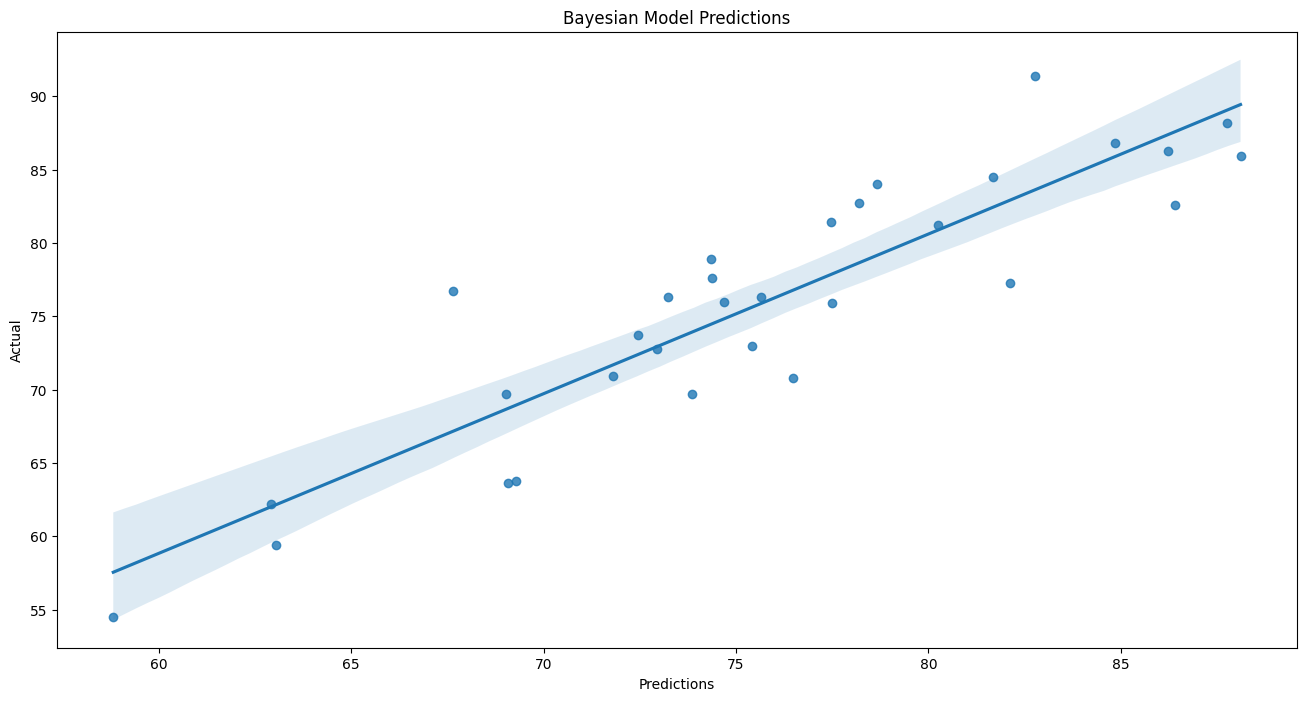

In [37]:
plt.figure(figsize=(16,8))
sns.regplot(x=test_predictions, y=y_test)
plt.xlabel('Predictions')
plt.ylabel('Actual')
plt.title("Bayesian Model Predictions")
plt.grid(False)
plt.show()

In [15]:
from sklearn.ensemble import RandomForestRegressor

clf2 = RandomForestRegressor()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=200)

# clf.fit(X_train, y_train)

In [16]:
# predicts = clf.predict(X_test)

# print("""
#         Mean Absolute Error: {}
#         Root Mean Squared Error: {}
#         R2 Score: {}
#      """.format(
#         mean_absolute_error(y_test,predicts),
#         np.sqrt(metrics.mean_squared_error(y_test, predicts)),
#         r2_score(y_test,predicts),
#         ))

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_mse = cross_val_score(clf2, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')

cv_rmse = np.sqrt(-cv_scores_mse)

print(f"Cross-Validation RMSE across 5 folds: {cv_rmse}")
print(f"Average CV RMSE: {cv_rmse.mean():.2f}")
print("-" * 30)

clf2.fit(X_train, y_train)

test_predictions = clf2.predict(X_test)

final_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
final_r2 = r2_score(y_test, test_predictions)

print(f"Final Test RMSE: {final_rmse:.2f}")
print(f"Final Test R2 Score: {final_r2:.2f}")

Cross-Validation RMSE across 5 folds: [5.50613863 6.91747398 5.36543257 6.32686385 7.24130139]
Average CV RMSE: 6.27
------------------------------
Final Test RMSE: 5.65
Final Test R2 Score: 0.59


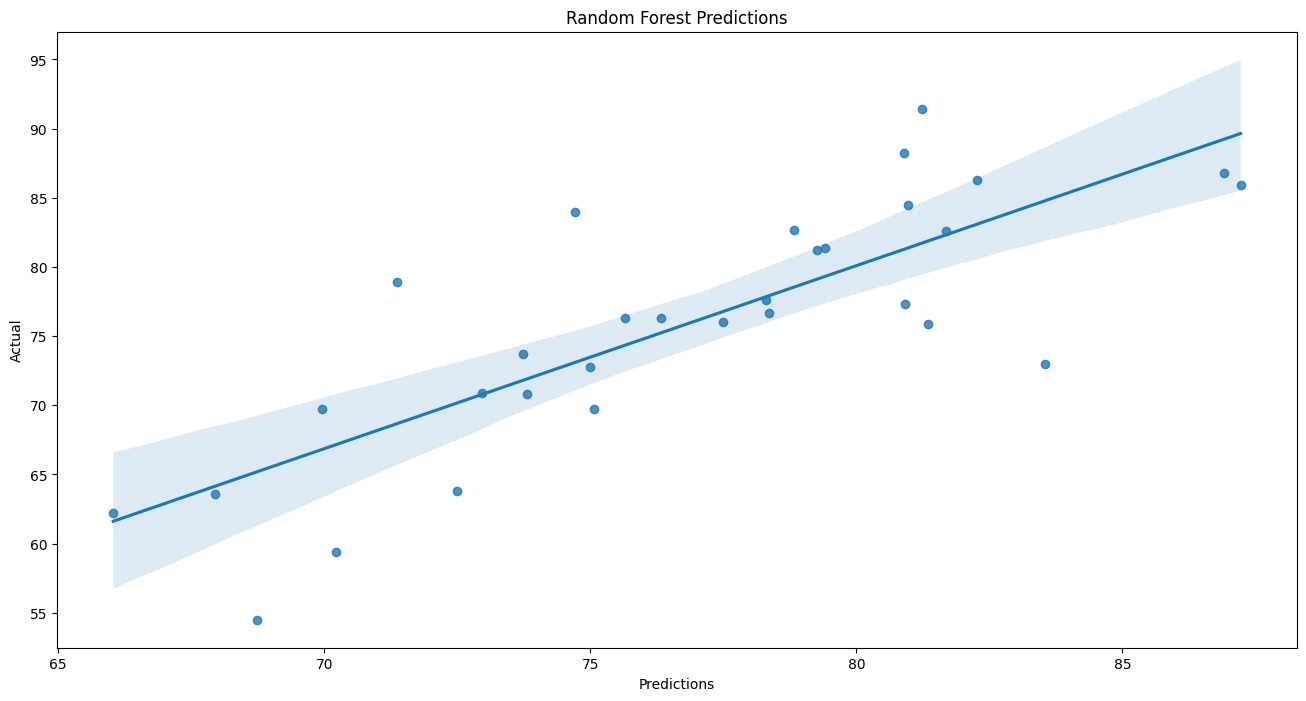

In [17]:
plt.figure(figsize=(16,8))
sns.regplot(x=test_predictions, y=y_test)
plt.xlabel('Predictions')
plt.ylabel('Actual')
plt.title("Random Forest Predictions")
plt.grid(False)
plt.show()

In [18]:
from sklearn.ensemble import GradientBoostingRegressor
clf3 = GradientBoostingRegressor()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=200)


In [19]:
# predicts = clf.predict(X_test)

# print("""
#         Mean Absolute Error: {}
#         Root Mean Squared Error: {}
#         R2 Score: {}
#      """.format(
#         mean_absolute_error(y_test,predicts),
#         np.sqrt(metrics.mean_squared_error(y_test, predicts)),
#         r2_score(y_test,predicts),
#         ))

kf = KFold(n_splits=5, shuffle=True, random_state=42)


cv_scores_mse = cross_val_score(clf3, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')


cv_rmse = np.sqrt(-cv_scores_mse)

print(f"Cross-Validation RMSE across 5 folds: {cv_rmse}")
print(f"Average CV RMSE: {cv_rmse.mean():.2f}")
print("-" * 30)


clf3.fit(X_train, y_train)

test_predictions = clf3.predict(X_test)

final_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
final_r2 = r2_score(y_test, test_predictions)

print(f"Final Test RMSE: {final_rmse:.2f}")
print(f"Final Test R2 Score: {final_r2:.2f}")

Cross-Validation RMSE across 5 folds: [5.85366334 7.19704682 6.02797247 5.87142486 6.55062748]
Average CV RMSE: 6.30
------------------------------
Final Test RMSE: 5.13
Final Test R2 Score: 0.66


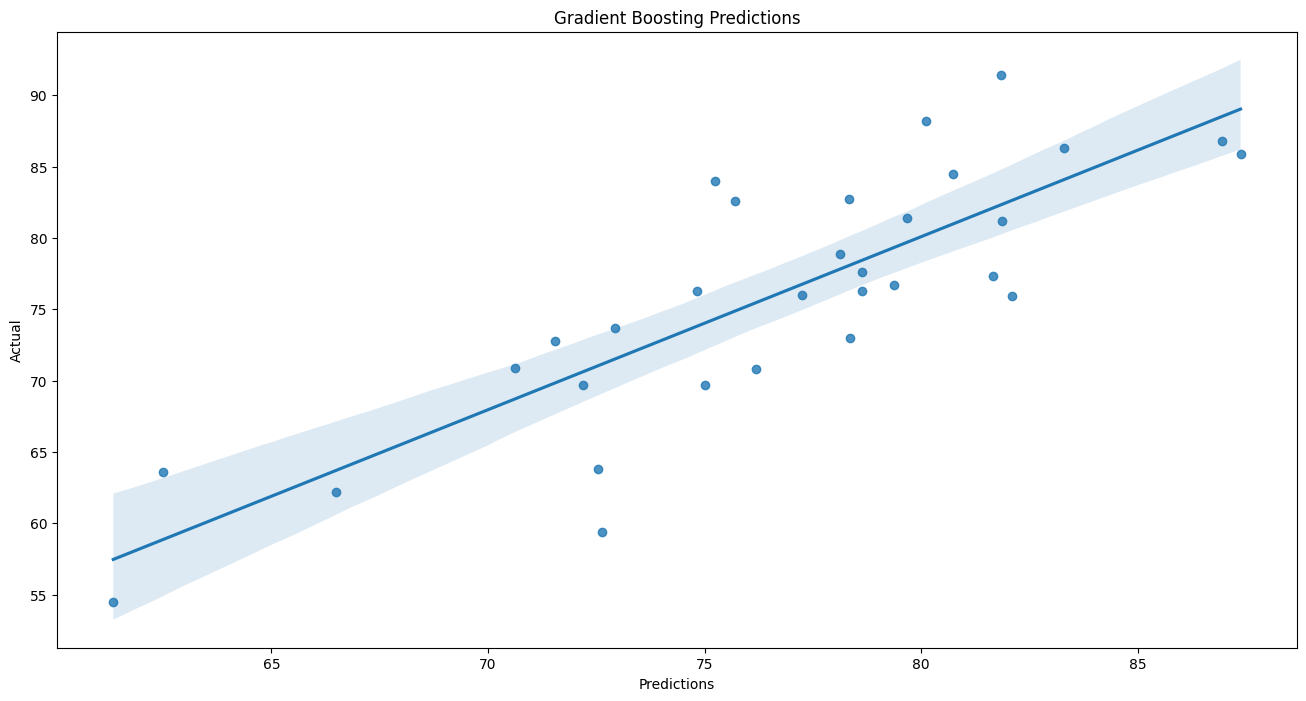

In [20]:
plt.figure(figsize=(16,8))
sns.regplot(x=test_predictions, y=y_test)
plt.xlabel('Predictions')
plt.ylabel('Actual')
plt.title("Gradient Boosting Predictions")
plt.grid(False)
plt.show()